<a href="https://colab.research.google.com/github/joaogcastro/machine-learning-fraudes-cartao/blob/main/ml_fraude_cartao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import warnings
warnings.filterwarnings("ignore")

csv_path = "creditcard - menor balanceado.csv"
df = pd.read_csv(csv_path)
print("Arquivo carregado de:", csv_path)
print("\n--- 5 primeiras linhas ---")
display(df.head())
print("\n--- Info ---")
print(df.info())
print("\n--- Distribuição da variável 'Class' ---")
dist = df['Class'].value_counts().rename_axis('Class').reset_index(name='counts')
dist['perc'] = 100 * dist['counts'] / dist['counts'].sum()
display(dist)

Arquivo carregado de: creditcard - menor balanceado.csv

--- 5 primeiras linhas ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
1,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
2,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
3,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
4,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1759 entries, 0 to 1758
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1759 non-null   float64
 1   V1      1759 non-null   float64
 2   V2      1759 non-null   float64
 3   V3      1759 non-null   float64
 4   V4      1759 non-null   float64
 5   V5      1759 non-null   float64
 6   V6      1759 non-null   float64
 7   V7      1759 non-null   float64
 8   V8      1759 non-null   float64
 9   V9      1759 non-null   float64
 10  V10     1759 non-null   float64
 11  V11     1759 non-null   float64
 12  V12     1759 non-null   float64
 13  V13     1759 non-null   float64
 14  V14     1759 non-null   float64
 15  V15     1759 non-null   float64
 16  V16     1759 non-null   float64
 17  V17     1759 non-null   float64
 18  V18     1759 non-null   float64
 19  V19     1759 non-null   float64
 20  V20     1759 non-null   float64
 21  V21     1759 non-null  

,Class,counts,perc
0,0,1267,72.029562
1,1,492,27.970438


<Figure size 600x400 with 0 Axes>

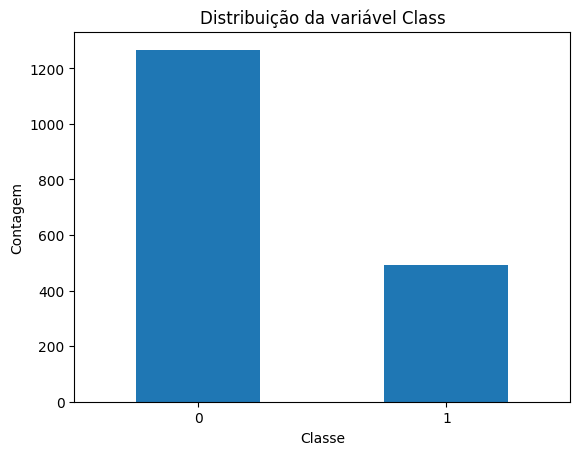

In [2]:
# Visualização da distribuição da variável 'Class'
plt.figure(figsize=(6, 4))
dist.plot(kind='bar', x='Class', y='counts', legend=False)
plt.title('Distribuição da variável Class')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

In [3]:
data = df.copy()
scaler = StandardScaler()
for col in ['Time', 'Amount']:
    if col in data.columns:
        data[col] = scaler.fit_transform(data[[col]])
X = data.drop(columns=['Class'])
y = data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"\nShapes -> X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")



Shapes -> X_train: (1407, 30), X_test: (352, 30), y_train: (1407,), y_test: (352,)


In [4]:
# Treinamos um modelo sem nenhuma técnica para comparação
baseline_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
baseline_clf.fit(X_train, y_train)
y_pred_base = baseline_clf.predict(X_test)
print("\n--- Baseline: RandomForest (padrão) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_base, digits=4))
print("Macro F1 (Baseline):", f1_score(y_test, y_pred_base, average='macro'))



--- Baseline: RandomForest (padrão) ---
Confusion Matrix:
[[253   1]
 [ 16  82]]

Classification Report (Baseline):
              precision    recall  f1-score   support

           0     0.9405    0.9961    0.9675       254
           1     0.9880    0.8367    0.9061        98

    accuracy                         0.9517       352
   macro avg     0.9642    0.9164    0.9368       352
weighted avg     0.9537    0.9517    0.9504       352

Macro F1 (Baseline): 0.9367862839757878


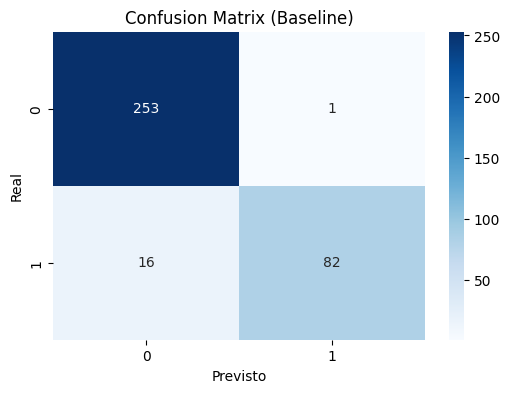

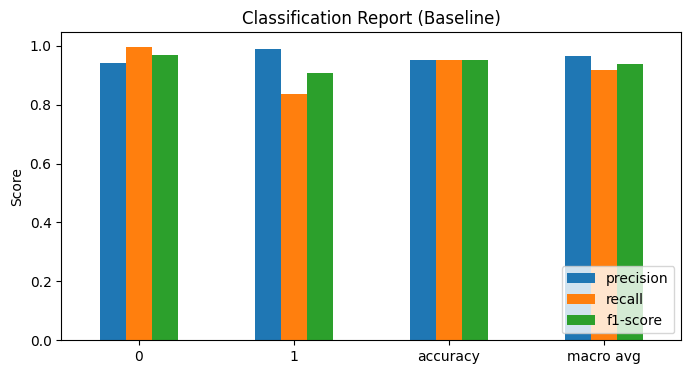

In [5]:
# Visualização da Confusion Matrix (Baseline)
import seaborn as sns
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# Visualização do Classification Report (Baseline) - Simplificada
report_base = classification_report(y_test, y_pred_base, digits=4, output_dict=True)
df_report_base = pd.DataFrame(report_base).transpose().iloc[:-1, :] # Remove accuracy, macro avg, weighted avg for plot
df_report_base = df_report_base[['precision', 'recall', 'f1-score']] # Select relevant metrics

fig, ax = plt.subplots(figsize=(8, 4))
df_report_base.plot(kind='bar', ax=ax)
plt.title('Classification Report (Baseline)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [6]:
rf_for_fs = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_for_fs.fit(X_train, y_train)
importances = pd.Series(rf_for_fs.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(importances.head(30))
K = min(20, X_train.shape[1])
top_features = importances.index[:K].tolist()
print(f"\nTop {K} features selecionadas: {top_features}")
X_train_fs = X_train[top_features].copy()
X_test_fs = X_test[top_features].copy()


,0
V14,0.155796
V10,0.145485
V17,0.103967
V12,0.101076
V4,0.087875
V11,0.070501
V16,0.063862
V3,0.061950
V2,0.029818
V9,0.022793



Top 20 features selecionadas: ['V14', 'V10', 'V17', 'V12', 'V4', 'V11', 'V16', 'V3', 'V2', 'V9', 'V7', 'V21', 'V6', 'V19', 'V18', 'V27', 'V15', 'V5', 'Amount', 'V20']


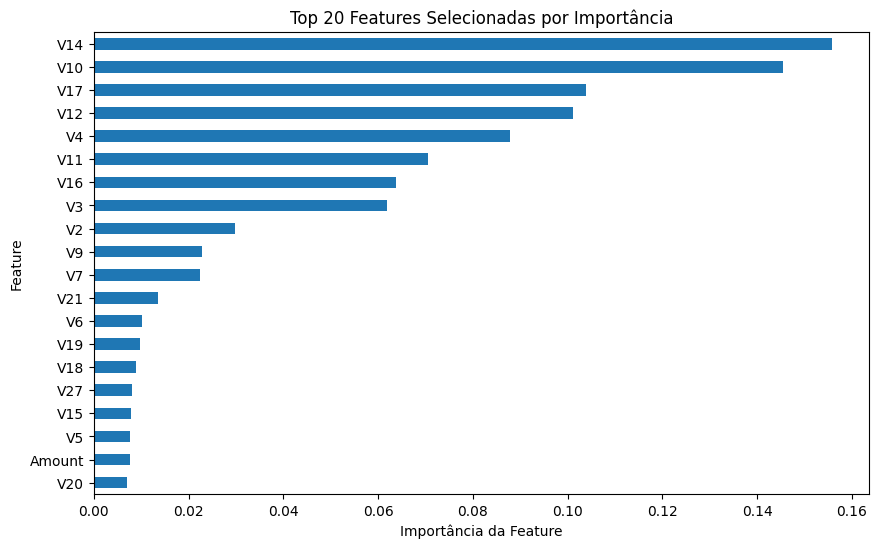

In [7]:
# Visualização das Top 20 Features Selecionadas
plt.figure(figsize=(10, 6))
importances.head(K).plot(kind='barh')
plt.title(f'Top {K} Features Selecionadas por Importância')
plt.xlabel('Importância da Feature')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Mostra a feature mais importante no topo
plt.show()

In [8]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_fs, y_train)
method_used = "SMOTE"

display(pd.Series(y_train_bal).value_counts())


,count
Class,
0,1013
1,1013


In [9]:
from sklearn.model_selection import RandomizedSearchCV

print("Iniciando Tuning com RandomizedSearchCV...")

param_dist = {'n_estimators': [100, 200, 300, 500],
              'max_features': ['sqrt', 'log2'],
              'max_depth': [10, 20, 30, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'bootstrap': [True, False]}

random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                                    param_distributions=param_dist,
                                    n_iter=10,
                                    cv=5,
                                    scoring='f1_macro',
                                    random_state=42,
                                    n_jobs=-1,
                                    verbose=1)

random_search.fit(X_train_bal, y_train_bal)

best_clf = random_search.best_estimator_
tuned = True
print("\nTuning concluído!")
print("Melhores parâmetros encontrados:", random_search.best_params_)

y_pred_best = best_clf.predict(X_test_fs)

print("\n--- Avaliação do melhor modelo (FS + Balanceamento + Tuning ou Fallback) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=4))
print("Macro F1 (Melhor Modelo):", f1_score(y_test, y_pred_best, average='macro'))

Iniciando Tuning com RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Tuning concluído!
Melhores parâmetros encontrados: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}

--- Avaliação do melhor modelo (FS + Balanceamento + Tuning ou Fallback) ---
Confusion Matrix:
[[253   1]
 [ 14  84]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9476    0.9961    0.9712       254
           1     0.9882    0.8571    0.9180        98

    accuracy                         0.9574       352
   macro avg     0.9679    0.9266    0.9446       352
weighted avg     0.9589    0.9574    0.9564       352

Macro F1 (Melhor Modelo): 0.9446209999685347


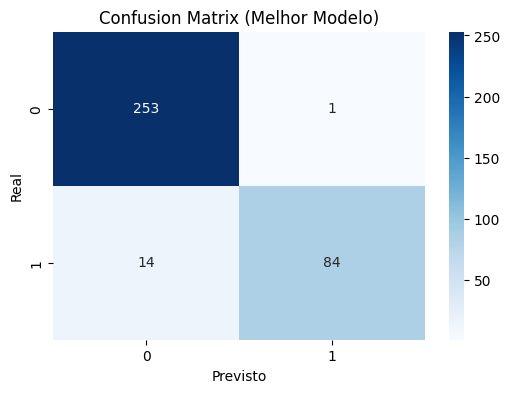

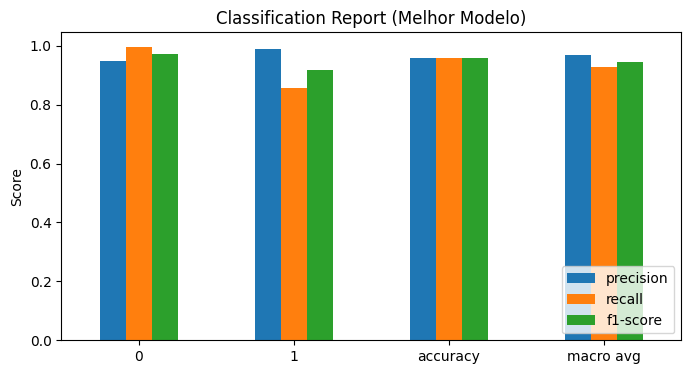

In [10]:
# Visualização da Confusion Matrix (Melhor Modelo)
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix (Melhor Modelo)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# Visualização do Classification Report (Melhor Modelo) - Simplificada
report_best = classification_report(y_test, y_pred_best, digits=4, output_dict=True)
df_report_best = pd.DataFrame(report_best).transpose().iloc[:-1, :]
df_report_best = df_report_best[['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(8, 4))
df_report_best.plot(kind='bar', ax=ax)
plt.title('Classification Report (Melhor Modelo)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [11]:
metrics = {}
metrics['baseline_macro_f1'] = f1_score(y_test, y_pred_base, average='macro')
metrics['best_macro_f1'] = f1_score(y_test, y_pred_best, average='macro')
print("\nComparação de Macro F1:")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")


Comparação de Macro F1:
baseline_macro_f1: 0.9368
best_macro_f1: 0.9446


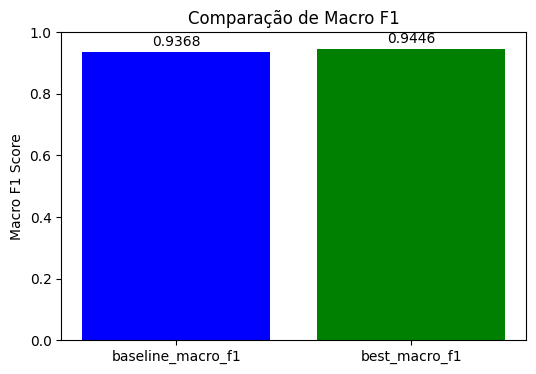

In [12]:
# Visualização da Comparação de Macro F1
plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green'])
plt.title('Comparação de Macro F1')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1) # Define o limite do eixo y de 0 a 1 para scores
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center') # Adiciona o valor acima da barra
plt.show()

Comparativo de Métricas:

Acurácia (Baseline): 0.9517
Acurácia (Melhor Modelo Tunado): 0.9574

Macro Avg F1-Score (Baseline): 0.9368
Macro Avg F1-Score (Melhor Modelo Tunado): 0.9446



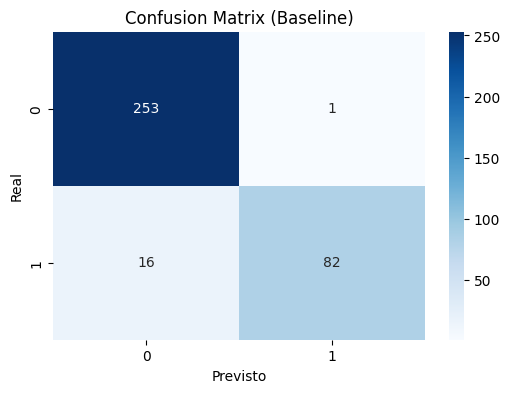

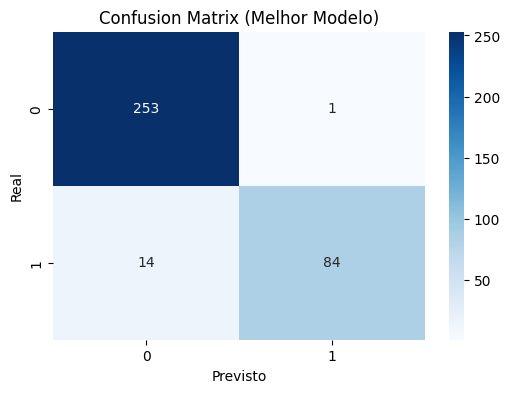

In [16]:
print("Comparativo de Métricas:")
print(f"\nAcurácia (Baseline): {report_base['accuracy']:.4f}")
print(f"Acurácia (Melhor Modelo Tunado): {report_best['accuracy']:.4f}")
print(f"\nMacro Avg F1-Score (Baseline): {report_base['macro avg']['f1-score']:.4f}")
print(f"Macro Avg F1-Score (Melhor Modelo Tunado): {report_best['macro avg']['f1-score']:.4f}\n")

# Visualização da Confusion Matrix (Baseline)
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# Visualização da Confusion Matrix (Melhor Modelo)
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix (Melhor Modelo)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

## Relatório de Análise de Modelos de Detecção de Fraude

Este notebook explorou a construção e otimização de um modelo de classificação para detecção de fraude em um dataset de transações de cartão de crédito. As principais etapas realizadas foram:

1.  **Carregamento e Análise Exploratória dos Dados:** Os dados foram carregados e a distribuição da variável target ('Class') foi analisada, revelando um desbalanceamento significativo entre transações legítimas (Classe 0) e fraudulentas (Classe 1).
2.  **Pré-processamento:** As features 'Time' e 'Amount' foram escalonadas utilizando `StandardScaler`. Os dados foram divididos em conjuntos de treino e teste de forma estratificada para manter a proporção das classes.
3.  **Modelo Baseline:** Um modelo `RandomForestClassifier` foi treinado nos dados originais (sem feature selection ou balanceamento) para estabelecer um ponto de comparação. As métricas de avaliação (Confusion Matrix, Classification Report, Macro F1) foram calculadas e visualizadas.
4.  **Feature Selection:** As 20 features mais importantes foram selecionadas com base na importância de features de um `RandomForestClassifier` treinado nos dados de treino.
5.  **Balanceamento de Classes:** A técnica SMOTE foi aplicada no conjunto de treino (com as features selecionadas) para balancear a distribuição das classes, gerando amostras sintéticas para a classe minoritária.
6.  **Tuning de Hiperparâmetros:** O `RandomizedSearchCV` foi utilizado para otimizar os hiperparâmetros do `RandomForestClassifier` no conjunto de treino balanceado, buscando maximizar o Macro F1 score.
7.  **Avaliação do Melhor Modelo:** O modelo com os melhores hiperparâmetros encontrados foi avaliado no conjunto de teste (com as features selecionadas).

**Comparação de Desempenho:**

A principal métrica de comparação utilizada foi o Macro F1 score, que é adequado para datasets desbalanceados.

*   **Macro F1 (Modelo Baseline):** 0.9368
*   **Macro F1 (Melhor Modelo Tunado):** 0.9446
*   **Acurácia (Baseline):** 0.9517
*   **Acurácia (Melhor Modelo Tunado):** 0.9574

**Conclusão:**

A aplicação das técnicas de Feature Selection, Balanceamento de Classes (SMOTE) e Tuning de Hiperparâmetros resultou em uma **melhora no desempenho do modelo**, evidenciada pelo aumento no Macro F1 score (de 0.9368 para 0.9446).

A matriz de confusão do melhor modelo também indicou uma ligeira redução nos Falsos Negativos (fraudes não detectadas) em comparação com o baseline.

Embora a melhora tenha sido modesta, as técnicas aplicadas foram eficazes em otimizar o modelo para este dataset. Melhorias adicionais poderiam ser exploradas testando diferentes números de features, variações do SMOTE ou outros algoritmos e espaços de tuning.